In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import cartopy.crs as ccrs
import cmocean.cm as cmo
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import optax
import xarray as xr

from jaxparrow.cyclogeostrophy import minimization_based
from jaxparrow.geostrophy import geostrophy
from jaxparrow.utils import kinematics


jax.config.update("jax_enable_x64", True)

This notebook demonstrates how regularization can be added to the minimization-based formulation of the cyclogeostrophic inversion problem, to deal with non-balanced SSH signal (for example).

## SWOT SSH observation

We use the filtered SSH (the sum of the variables ``mdt`` and ``ssha_filtered``) measured by SWOT, distributed in version 3_0 of the product from Aviso.

In [3]:
def get_med_sea(swot_ds):
    med_mask = (
        (swot_ds["latitude"] > 30.0681) & (swot_ds["latitude"] < 47.3764) & 
        (swot_ds["longitude"] > -6.0326) & (swot_ds["longitude"] < 42.355)
    )
    swot_ds = swot_ds.where(med_mask, drop=True)

    sea_mask = ~np.isnan(swot_ds["ssha_filtered"])
    min_lat, max_lat = swot_ds["latitude"].where(sea_mask).min(), swot_ds["latitude"].where(sea_mask).max()
    min_lon, max_lon = swot_ds["longitude"].where(sea_mask).min(), swot_ds["longitude"].where(sea_mask).max()
    
    swot_ds = swot_ds.where(
        (swot_ds["latitude"] >= min_lat) & (swot_ds["latitude"] <= max_lat) &
        (swot_ds["longitude"] >= min_lon) & (swot_ds["longitude"] <= max_lon),
        drop=True
    )

    return swot_ds


swot_003_ds = xr.open_dataset("data/SWOT/SWOT_L3_LR_SSH_Expert_506_003_20230429T184429_20230429T193535_v3.0.nc")
swot_003_ds = get_med_sea(swot_003_ds)

We can see that this SSH signal is relatively smooth, but shows small structures that are likely not balanced.

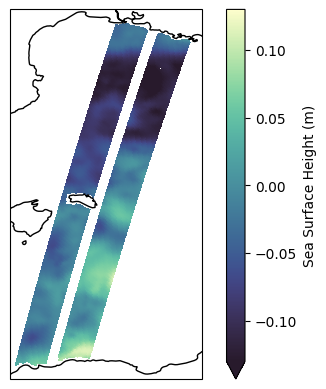

In [4]:
qm = (swot_003_ds.ssha_filtered + swot_003_ds.mdt).plot.pcolormesh(
    x="longitude", y="latitude", 
    cmap=cmo.deep_r, add_colorbar=True, robust=True,
    cbar_kwargs={"label": "Sea Surface Height (m)"},
    subplot_kws={"projection": ccrs.PlateCarree()}
)

qm.axes.coastlines()

plt.show()

## Regularization

We will see the impact of adding a regularization term on the vorticity with respect to either the cyclogeostrophic velocity field, the geostrophic velocity field, or the original SSH field.

In all cases, it simply resolves to writing a JAX-friendly regularization function taking as arguments the latitude and longitude arrays, and either the (cyclo)geostrophic velocity field or the SSH field, and returning a scalar value. Additional arguments can also be provided, we refer the reader to the API documentation of the [`minimization_based`](../api.md#jaxparrow.cyclogeostrophy.minimization_based) function.

In [5]:
lat = jnp.asarray(swot_003_ds.latitude.values)
lon = jnp.asarray(swot_003_ds.longitude.values)
ssh = jnp.asarray((swot_003_ds.ssha_filtered + swot_003_ds.mdt).values)

mb_results_noreg = minimization_based(
    lat_t=lat, lon_t=lon, ssh_t=ssh, optim=optax.chain(optax.clip(1), optax.sgd(learning_rate=5e-3))
)

### With respect to the cyclogeostrophic velocity field

In this case the signature (i.e. the parameters) of the regularization function must contain ``ucg_t`` and ``vcg_t`` as arguments for the components of the cyclogeostrophic velocity field, and ``lat_t`` and ``lon_t`` as arguments for the grid coordinate arrays. The order of the arguments does not matter, but their exact spelling does.

The regularization function can contain any instructions that are compatible with JAX ``grad`` and ``jit`` barriers.
Here we simply use the [`vorticity`](../api.md#jaxparrow.kinematics.vorticity) function from ``jaxparrow`` to compute the relative vorticity of the velocity field, we square it, and we return its sum over the whole geographical domain.

In [6]:
lambda_reg_cg = 1e-1

def regularization_cg(ucg_t, vcg_t, lat_t, lon_t):
    vort = kinematics.vorticity(ucg_t, vcg_t, lat_t, lon_t)
    reg = lambda_reg_cg * jnp.nansum(vort**2)
    return reg

We then pass this function as an argument to [`minimization_based`](../api.md#jaxparrow.cyclogeostrophy.minimization_based) when performing the inversion.

In [7]:
mb_results_cg = minimization_based(
    lat_t=lat, lon_t=lon, ssh_t=ssh, 
    optim=optax.chain(optax.clip(1), optax.sgd(learning_rate=5e-3)), 
    regularization=regularization_cg
)

### With respect to the geostrophic velocity field

As in the previous example, the regularization function must contain ``lat_t`` and ``lon_t`` as arguments for the grid coordinate arrays, and this time ``ug_t`` and ``vg_t`` as arguments for the components of the geostrophic velocity field.

Again, we use the [`vorticity`](../api.md#jaxparrow.kinematics.vorticity) function from ``jaxparrow`` to compute the relative vorticity of the velocity field, but using the geostrophic currents.

In [8]:
lambda_reg_g = 7e-3

def regularization_g(ug_t, vg_t, lat_t, lon_t):
    vort = kinematics.vorticity(ug_t, vg_t, lat_t, lon_t)
    reg = lambda_reg_g * jnp.nansum(vort**2)
    return reg

And we solve the optimization problem.

In [9]:
mb_results_g = minimization_based(
    lat_t=lat, lon_t=lon, ssh_t=ssh, 
    optim=optax.chain(optax.clip(1), optax.sgd(learning_rate=5e-3)), 
    regularization=regularization_g
)

### With respect to the SSH field

Now only ``ssh_t`` must be provided as an argument for the SSH field (and of course ``lat_t`` and ``lon_t``).

Using the SSH field, we compute the geostrophic currents, from which we get the vorticity (we could have used the Laplacian of the SSH as well).

In [10]:
lambda_reg_ssh = 1e-5

def regularization_ssh(ssh_t, lat_t, lon_t):
    ug, vg = geostrophy(ssh_t, lat_t, lon_t)
    vort = kinematics.vorticity(ug, vg, lat_t, lon_t)
    reg = lambda_reg_ssh * jnp.nansum(vort**2)
    return reg

In [11]:
mb_results_ssh = minimization_based(
    lat_t=lat, lon_t=lon, ssh_t=ssh, 
    optim=optax.chain(optax.clip(1), optax.sgd(learning_rate=5e-3)), regularization=regularization_ssh
)

## Comparison

We now visually observe the difference between the SSH, cyclogeostrophic velocity, and cyclogeostrophic relative vorticity fields obtained from the different regularization variants (including no regularization).

In [12]:
ssh_reg_cg = mb_results_cg.ssh if mb_results_cg.ssh is not None else ssh
ssh_reg_g = mb_results_g.ssh if mb_results_g.ssh is not None else ssh
ssh_reg_ssh = mb_results_ssh.ssh if mb_results_ssh.ssh is not None else ssh

ucg_reg_cg = mb_results_cg.ucg
ucg_reg_g = mb_results_g.ucg
ucg_reg_ssh = mb_results_ssh.ucg
ucg_noreg = mb_results_noreg.ucg

vcg_reg_cg = mb_results_cg.vcg
vcg_reg_g = mb_results_g.vcg
vcg_reg_ssh = mb_results_ssh.vcg
vcg_noreg = mb_results_noreg.vcg

In [13]:
uvcg_reg_cg = kinematics.magnitude(ucg_reg_cg, vcg_reg_cg)
uvcg_reg_g = kinematics.magnitude(ucg_reg_g, vcg_reg_g)
uvcg_reg_ssh = kinematics.magnitude(ucg_reg_ssh, vcg_reg_ssh)
uvcg_noreg = kinematics.magnitude(ucg_noreg, vcg_noreg)

rv_reg_cg = kinematics.vorticity(ucg_reg_cg, vcg_reg_cg, lat, lon)
rv_reg_g = kinematics.vorticity(ucg_reg_g, vcg_reg_g, lat, lon)
rv_reg_ssh = kinematics.vorticity(ucg_reg_ssh, vcg_reg_ssh, lat, lon)
rv_noreg = kinematics.vorticity(ucg_noreg, vcg_noreg, lat, lon)

In [14]:
ssh_reg_cg_da = xr.DataArray(
    ssh_reg_cg,
    coords={"latitude": swot_003_ds["latitude"], "longitude": swot_003_ds["longitude"]},
    dims=("num_lines", "num_pixels")
)
ssh_reg_g_da = xr.DataArray(
    ssh_reg_g,
    coords={"latitude": swot_003_ds["latitude"], "longitude": swot_003_ds["longitude"]},
    dims=("num_lines", "num_pixels")
)
ssh_reg_ssh_da = xr.DataArray(
    ssh_reg_ssh,
    coords={"latitude": swot_003_ds["latitude"], "longitude": swot_003_ds["longitude"]},
    dims=("num_lines", "num_pixels")
)
ssh_noreg_da = xr.DataArray(
    ssh,
    coords={"latitude": swot_003_ds["latitude"], "longitude": swot_003_ds["longitude"]},
    dims=("num_lines", "num_pixels")
)

uvcg_reg_cg_da = xr.DataArray(
    uvcg_reg_cg,
    coords={"latitude": swot_003_ds["latitude"], "longitude": swot_003_ds["longitude"]},
    dims=("num_lines", "num_pixels")
)
uvcg_reg_g_da = xr.DataArray(
    uvcg_reg_g,
    coords={"latitude": swot_003_ds["latitude"], "longitude": swot_003_ds["longitude"]},
    dims=("num_lines", "num_pixels")
)
uvcg_reg_ssh_da = xr.DataArray(
    uvcg_reg_ssh,
    coords={"latitude": swot_003_ds["latitude"], "longitude": swot_003_ds["longitude"]},
    dims=("num_lines", "num_pixels")
)
uvcg_noreg_da = xr.DataArray(
    uvcg_noreg,
    coords={"latitude": swot_003_ds["latitude"], "longitude": swot_003_ds["longitude"]},
    dims=("num_lines", "num_pixels")
)

rv_reg_cg_da = xr.DataArray(
    rv_reg_cg,
    coords={"latitude": swot_003_ds["latitude"], "longitude": swot_003_ds["longitude"]},
    dims=("num_lines", "num_pixels")
)
rv_reg_g_da = xr.DataArray(
    rv_reg_g,
    coords={"latitude": swot_003_ds["latitude"], "longitude": swot_003_ds["longitude"]},
    dims=("num_lines", "num_pixels")
)
rv_reg_ssh_da = xr.DataArray(
    rv_reg_ssh,
    coords={"latitude": swot_003_ds["latitude"], "longitude": swot_003_ds["longitude"]},
    dims=("num_lines", "num_pixels")
)
rv_noreg_da = xr.DataArray(
    rv_noreg,
    coords={"latitude": swot_003_ds["latitude"], "longitude": swot_003_ds["longitude"]},
    dims=("num_lines", "num_pixels")
)

In [15]:
methods = ["None", "Cyclogeos.", "Geos.", "SSH"]

ssh_da = xr.concat(
    [ssh_noreg_da, ssh_reg_cg_da, ssh_reg_g_da, ssh_reg_ssh_da], 
    dim=xr.Variable("regularization", methods)
)
uvcg_da = xr.concat(
    [uvcg_noreg_da, uvcg_reg_cg_da, uvcg_reg_g_da, uvcg_reg_ssh_da], 
    dim=xr.Variable("regularization", methods)
)
rv_da = xr.concat(
    [rv_noreg_da, rv_reg_cg_da, rv_reg_g_da, rv_reg_ssh_da], 
    dim=xr.Variable("regularization", methods)
)

In [16]:
row_labels = methods[:-1]  # subtracted from
col_labels = methods[1:]   # subtracted

def build_diff_da(fields):
    diff_data = np.full((len(row_labels), len(col_labels)) + fields[0].shape, np.nan)
    for i in range(len(row_labels)):
        for j in range(len(col_labels)):
            if i <= j:  # upper triangle
                diff_data[i, j] = np.array(fields[j + 1] - fields[i])
    return xr.DataArray(
        diff_data,
        dims=("row", "col", "num_lines", "num_pixels"),
        coords={
            "row": row_labels, "col": col_labels,
            "latitude": (("num_lines", "num_pixels"), swot_003_ds["latitude"].values),
            "longitude": (("num_lines", "num_pixels"), swot_003_ds["longitude"].values),
        },
    )

def plot_diff_triangle(da, cmap, cbar_label):
    fg = da.plot.pcolormesh(
        x="longitude", y="latitude", row="row", col="col",
        cmap=cmap, robust=True, add_colorbar=True,
        cbar_kwargs={"label": cbar_label, "aspect": 35},
        figsize=(7, 10),
        subplot_kws={"projection": ccrs.PlateCarree()},
    )
    fg.set_titles("{value}")
    for i, ax in enumerate(fg.axs.flat):
        row_idx, col_idx = divmod(i, len(col_labels))
        if row_idx > col_idx:
            ax.set_visible(False)
        else:
            ax.coastlines()
    plt.show()

For the SSH field, only the one from the variant in which the regularization is performed directly on the SSH was modified.

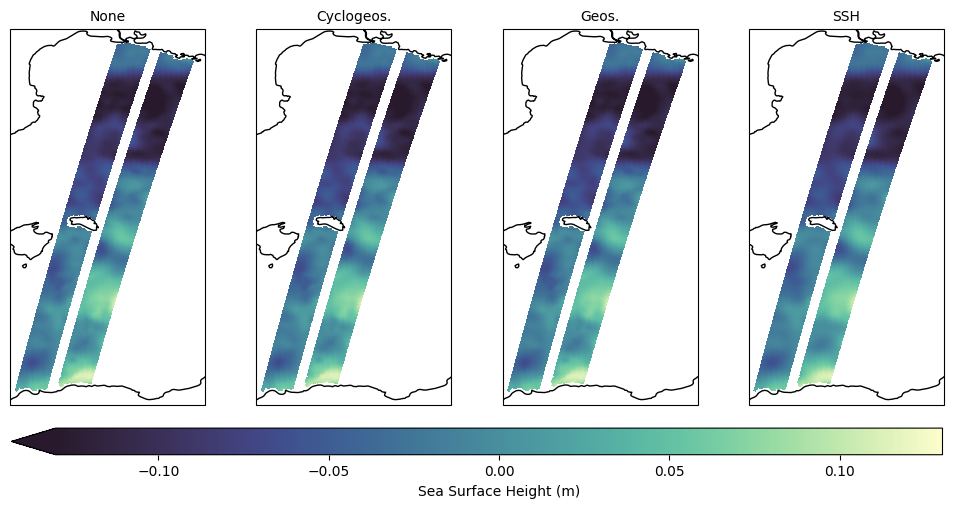

In [17]:
fg = ssh_da.plot.pcolormesh(
    x="longitude", y="latitude", col="regularization",
    cmap=cmo.deep_r, add_colorbar=True, robust=True,
    cbar_kwargs={"label": "Sea Surface Height (m)", "location": "bottom", "shrink": 0.96, "aspect": 35, "pad": 0.05},
    figsize=(10, 5), subplot_kws={"projection": ccrs.PlateCarree()}
)

fg.set_titles("{value}")
for ax in fg.axs.flat:
    ax.coastlines()

plt.show()

And when looking at the difference between the fields, we see that we filtered some small-scale structures.

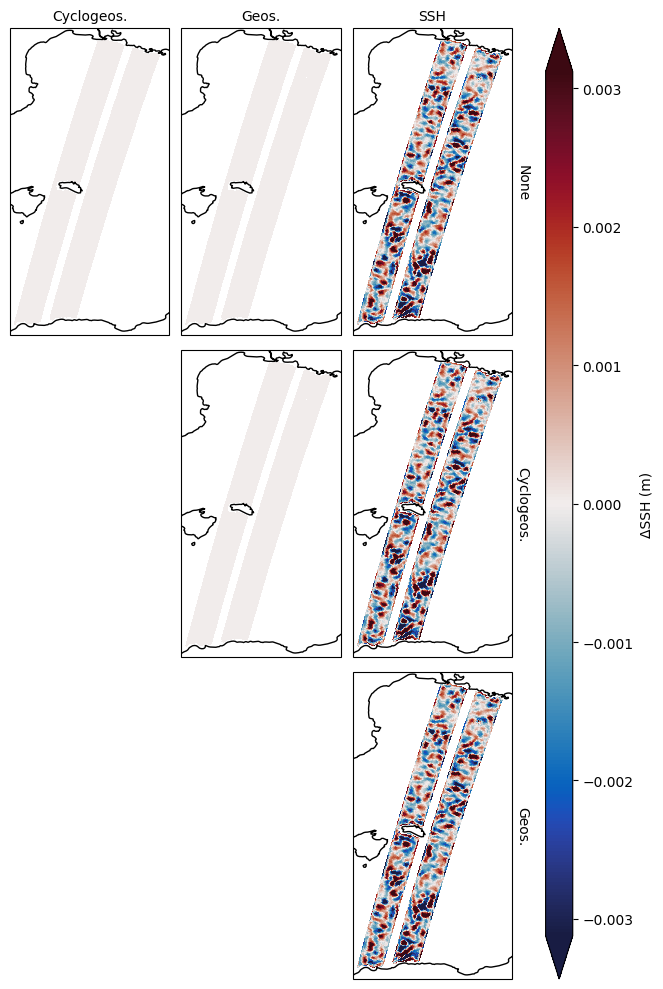

In [18]:
ssh_diff_da = build_diff_da([ssh_noreg_da, ssh_reg_cg_da, ssh_reg_g_da, ssh_reg_ssh_da])
plot_diff_triangle(ssh_diff_da, cmo.balance, "ΔSSH (m)")

The cyclogeostrophic velocity fields are this time all different from one another, and we again see that the three regularization variants filtered out some small structures.

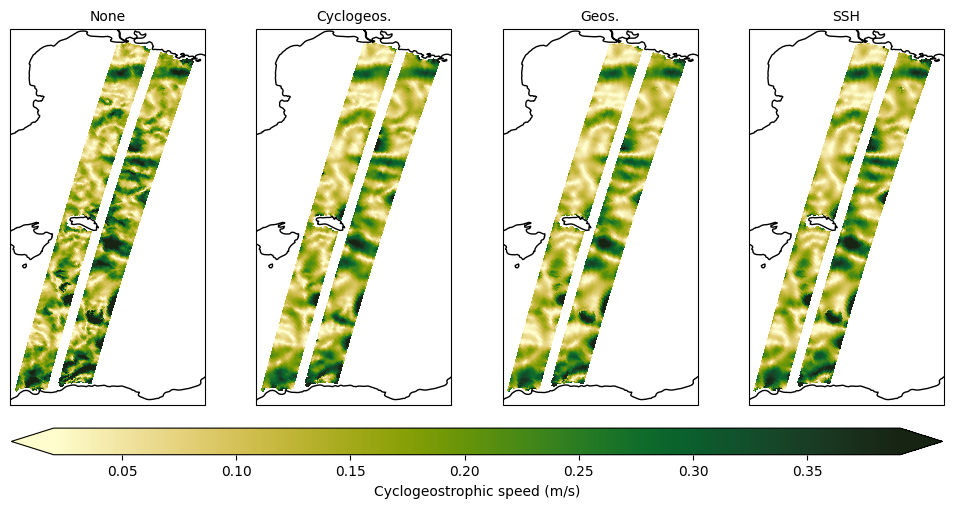

In [19]:
fg = uvcg_da.plot.pcolormesh(
    x="longitude", y="latitude", col="regularization",
    cmap=cmo.speed, add_colorbar=True, robust=True,
    cbar_kwargs={
        "label": "Cyclogeostrophic speed (m/s)", "location": "bottom", "shrink": 0.96, "aspect": 35, "pad": 0.05
    },
    figsize=(10, 5), subplot_kws={"projection": ccrs.PlateCarree()}
)

fg.set_titles("{value}")
for ax in fg.axs.flat:
    ax.coastlines()

plt.show()

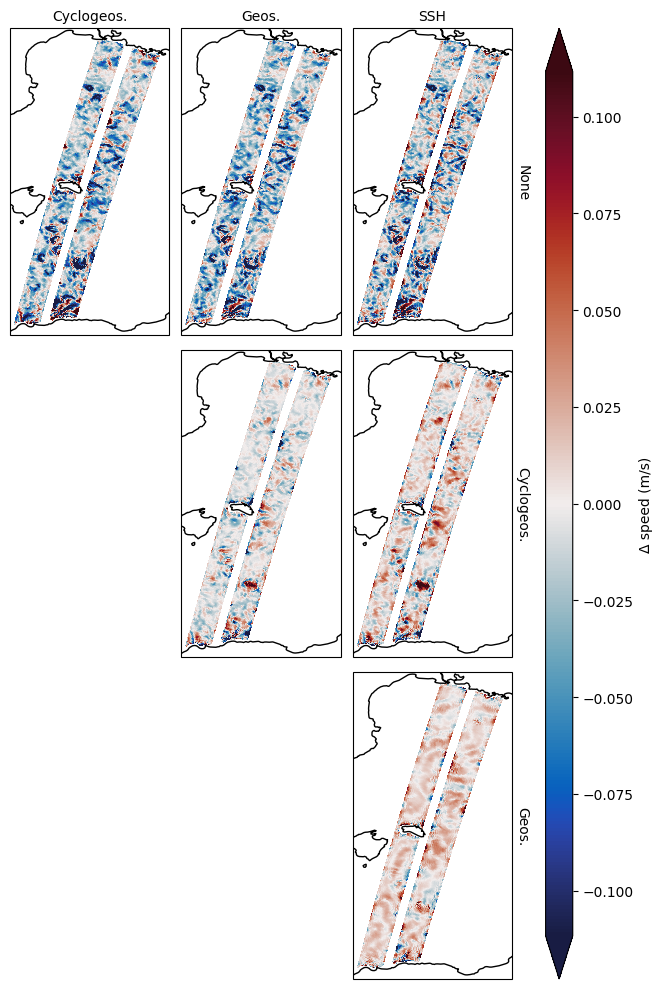

In [20]:
uvcg_diff_da = build_diff_da([uvcg_noreg_da, uvcg_reg_cg_da, uvcg_reg_g_da, uvcg_reg_ssh_da])
plot_diff_triangle(uvcg_diff_da, cmo.balance, "Δ speed (m/s)")

Finally, when inspecting the relative vorticity fields, we observe that the one obtained with the regularization applied to the cyclogeostrophic velocity is overall smoother and looks physically more consistent than the others.

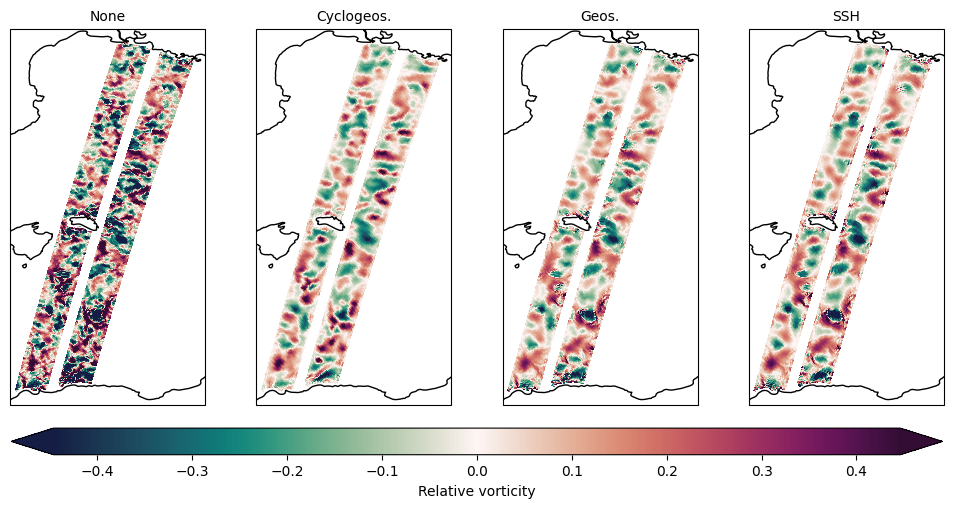

In [21]:
fg = rv_da.plot.pcolormesh(
    x="longitude", y="latitude", col="regularization",
    cmap=cmo.curl, add_colorbar=True, robust=True,
    cbar_kwargs={"label": "Relative vorticity", "location": "bottom", "shrink": 0.96, "aspect": 35, "pad": 0.05},
    figsize=(10, 5), subplot_kws={"projection": ccrs.PlateCarree()}
)

fg.set_titles("{value}")
for ax in fg.axs.flat:
    ax.coastlines()

plt.show()

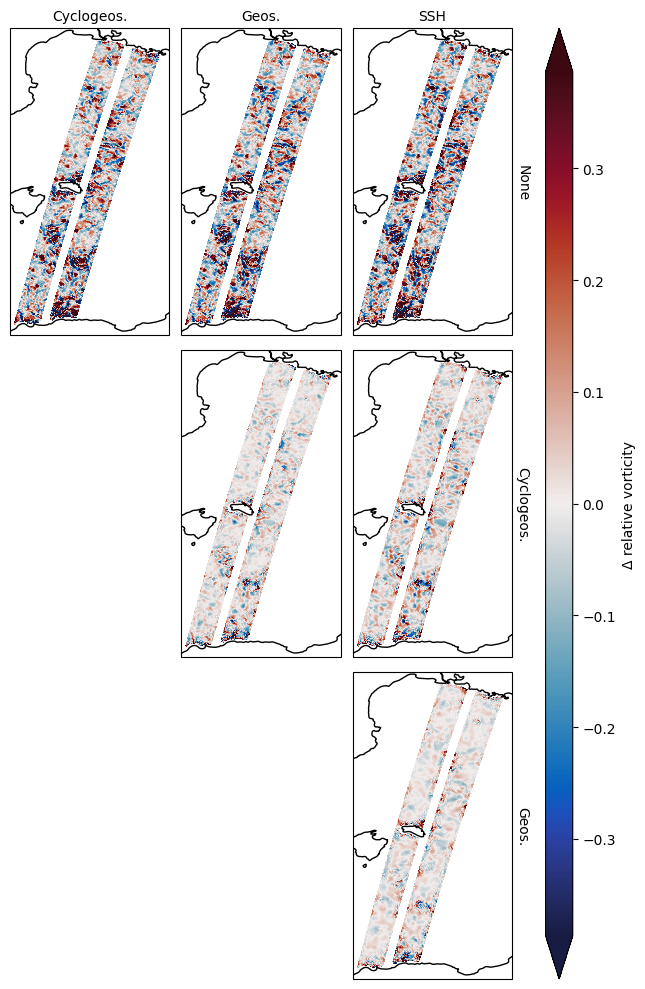

In [22]:
rv_diff_da = build_diff_da([rv_noreg_da, rv_reg_cg_da, rv_reg_g_da, rv_reg_ssh_da])
plot_diff_triangle(rv_diff_da, cmo.balance, "Δ relative vorticity")